# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime as dt
import pickle

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [ ]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = 'online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

In [ ]:
df.to_pickle('online_retail.pkl')


In [5]:
df = pd.read_pickle('online_retail.pkl')

## 2. Primera inspección

In [6]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [8]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [9]:
df.shape

(1067371, 8)

## 3. Calidad de datos

In [10]:
# chequear nulos y duplicados

df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [11]:
# Proporcion de nulos de cada columna del dataset

for col in df.columns:
    n_nans = df[col].isna().sum()
    print(f'{col} : {n_nans/len(df[col])}')

Invoice : 0.0
StockCode : 0.0
Description : 0.0041054141437232225
Quantity : 0.0
InvoiceDate : 0.0
Price : 0.0
Customer ID : 0.22766872999172733
Country : 0.0


In [12]:
# Eliminar registros sin ID de cliente

df = df.dropna(subset=['Customer ID'])

In [13]:
# Comprobamos el número de devoluciones que tiene el dataset

df[df['Invoice'].astype(str).str.startswith('C') == True].count()

Invoice        18744
StockCode      18744
Description    18744
Quantity       18744
InvoiceDate    18744
Price          18744
Customer ID    18744
Country        18744
dtype: int64

In [14]:
(df[df['Invoice'].astype(str).str.startswith('C') == True].shape[0] / df[~df['Invoice'].astype(str).str.startswith('C') == True].shape[0]) * 100

2.3266552468905934

## Análisis de ventas

- Al decidir quitar las facturas de devoluciones, tenemos que tener en cuenta el impacto que tiene en nuestras ventas netas.

In [15]:
df['TotalSales'] = df['Quantity'] * df['Price']

ventas = df.groupby('Customer ID').agg(
    Facturacion_Total=('TotalSales', 'sum'),  # Suma de todos sus tickets (Monetario)
    Num_Compras=('Invoice', 'nunique')   # Número de facturas distintas (Frequencia)
).reset_index()

# 1. Calculamos las ventas netas actuales (con las "C" incluidas)
ventas_con_c = df['TotalSales'].sum()

# 2. Filtramos el DataFrame para simular cómo quedaría SIN las facturas "C"
# (Asumiendo que identificas las cancelaciones si el InvoiceNo empieza por 'C')
df_sin_c = df[~df['Invoice'].astype(str).str.startswith('C')]
ventas_sin_c = df_sin_c['TotalSales'].sum()

# 3. Calculamos la alteración porcentual
alteracion_porcentual = ((ventas_sin_c - ventas_con_c) / ventas_con_c) * 100

print(f"Ventas Netas Actuales (Con C): £{ventas_con_c:,.2f}")
print(f"Ventas Netas Limpias (Sin C):  £{ventas_sin_c:,.2f}")
print(f"Las ventas netas se alteran en un: {alteracion_porcentual:.2f}%")

Ventas Netas Actuales (Con C): £16,648,292.39
Ventas Netas Limpias (Sin C):  £17,743,429.18
Las ventas netas se alteran en un: 6.58%


In [16]:
# Quitamos las facturas de devoluciones aun sabiendo que alteran las ventas netas, es para viabilidad de un MVP

df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [17]:
# Llenamos las descripciones nulos con UNKNOWN PRODUCT

df['Description'] = df['Description'].fillna('UNKNOWN PRODUCT')

In [18]:
# Contar filas 100% duplicadas
total_duplicados = df.duplicated().sum()
print(f"Número de filas totalmente duplicadas: {total_duplicados}")

# Eliminarlos y quedarte solo con la primera ocurrencia
df = df.drop_duplicates(keep='first')
print(f"Dataset limpio. Filas restantes: {len(df)}")

Número de filas totalmente duplicadas: 26125
Dataset limpio. Filas restantes: 779495


## Sanity Checks

In [19]:
print("==================================================")
print("   INICIANDO CONTROLES SANITARIOS (SANITY CHECKS) ")
print("==================================================\n")

# Control de Precios e Ingresos anomalos
precios_negativos = df[df['Price'] < 0]
precios_cero = df[df['Price'] == 0]
print(f"[ALERTA] Registros con Precio NEGATIVO: {len(precios_negativos)}")
print(f"[AVISO] Registros con Precio IGUAL A CERO: {len(precios_cero)}")

# Control de Cantidades (Quantity)
# Ya quitamos las cancelaciones ('C'), por lo que no debería haber cantidades negativas
cantidades_negativas = df[df['Quantity'] < 0]
cantidades_cero = df[df['Quantity'] == 0]
print(f"[ALERTA] Registros con Cantidad NEGATIVA (sin 'C'): {len(cantidades_negativas)}")
print(f"[AVISO] Registros con Cantidad IGUAL A CERO: {len(cantidades_cero)}")

# Control de Identificadores Críticos (Customer ID y Invoice)
nulos_customer = df['Customer ID'].isnull().sum()
print(f"[CRÍTICO] Registros con 'Customer ID' NULO o VACÍO: {nulos_customer}")

# Control de Códigos de Stock Sospechosos (Ajustes manuales, tasas, etc.)
codigos_no_productos = df[df['StockCode'].astype(str).str.contains('^[a-zA-Z]+$', regex=True)]
print(f"[AVISO] Registros con StockCode que son solo texto (envíos, comisiones, manuales): {codigos_no_productos['StockCode'].unique()}")
print(f"        Total de filas afectadas por estos códigos: {len(codigos_no_productos)}")

# Control de Fechas Lógicas
fechas_futuras = df[df['InvoiceDate'] > pd.Timestamp.now()]
print(f"[ALERTA] Registros con fechas en el futuro: {len(fechas_futuras)}")

print("\n==================================================")
print("         FIN DEL REPORTE DE SANITY CHECKS         ")
print("==================================================")

   INICIANDO CONTROLES SANITARIOS (SANITY CHECKS) 

[ALERTA] Registros con Precio NEGATIVO: 0
[AVISO] Registros con Precio IGUAL A CERO: 70
[ALERTA] Registros con Cantidad NEGATIVA (sin 'C'): 0
[AVISO] Registros con Cantidad IGUAL A CERO: 0
[CRÍTICO] Registros con 'Customer ID' NULO o VACÍO: 0
[AVISO] Registros con StockCode que son solo texto (envíos, comisiones, manuales): ['POST' 'M' 'PADS' 'ADJUST' 'D' 'DOT']
        Total de filas afectadas por estos códigos: 2562
[ALERTA] Registros con fechas en el futuro: 0

         FIN DEL REPORTE DE SANITY CHECKS         


In [20]:

# Filtramos el dataset aplicando todas las reglas de negocio aprendidas
df = df[
    # Evitar nulos en clientes (obligatorio para trackear recompra)
    (df['Customer ID'].notnull()) & 
    
    # Precios y cantidades estrictamente mayores que cero
    (df['Price'] > 0) & 
    (df['Quantity'] > 0) 
].copy()

### Transformaciones de datos

In [21]:
# fraccionamos la columna de fecha en periodos para extraer insights 

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

## 4. Estadísticas descriptivas

In [22]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalSales,Year,Month,Day,Hour,DayOfWeek
count,779425.000000,779425,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461,22.291823,2010.432051,7.417059,15.390961,12.791884,2.641669
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,6.000000,0.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000,2010.000000,5.000000,8.000000,11.000000,1.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000,2010.000000,8.000000,15.000000,13.000000,2.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000,2011.000000,11.000000,23.000000,14.000000,4.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000,6.000000
std,145.855814,NaN,29.676140,1695.692775,227.427075,0.568385,3.422319,8.657939,2.294182,1.951163


In [23]:
# Separamos variables categoricas de las numéricas

def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

In [24]:
# Commplementamos el describe() con otras medidas de estadística descriptiva

stats_df = df[num_vbles].describe().T
stats_df['median'] = df[num_vbles].median()
stats_df['mode'] = df[num_vbles].mode().iloc[0]
stats_df['variance'] = df[num_vbles].var()
stats_df['skewness'] = df[num_vbles].skew()
stats_df['kurtosis'] = df[num_vbles].kurt()

stats_df

,count,mean,std,min,25%,50%,75%,max,median,mode,variance,skewness,kurtosis
Quantity,779425.0,13.489370,145.855814,1.000,2.00,6.00,12.00,80995.0,6.00,1.00,2.127392e+04,401.117592,208835.588829
Price,779425.0,3.218488,29.676140,0.001,1.25,1.95,3.75,10953.5,1.95,1.25,8.806733e+02,240.546429,71987.189638
Customer ID,779425.0,15320.360461,1695.692775,12346.000,13971.00,15247.00,16794.00,18287.0,15247.00,17841.00,2.875374e+06,0.009901,-1.183337
TotalSales,779425.0,22.291823,227.427075,0.001,4.95,12.48,19.80,168469.6,12.48,15.00,5.172307e+04,579.574978,404279.970678
Year,779425.0,2010.432051,0.568385,2009.000,2010.00,2010.00,2011.00,2011.0,2010.00,2010.00,3.230611e-01,-0.366704,-0.801799
Month,779425.0,7.417059,3.422319,1.000,5.00,8.00,11.00,12.0,8.00,11.00,1.171227e+01,-0.363997,-1.156559
Day,779425.0,15.390961,8.657939,1.000,8.00,15.00,23.00,31.0,15.00,7.00,7.495992e+01,0.057454,-1.175672
Hour,779425.0,12.791884,2.294182,6.000,11.00,13.00,14.00,20.0,13.00,12.00,5.263269e+00,0.217713,-0.172471
DayOfWeek,779425.0,2.641669,1.951163,0.000,1.00,2.00,4.00,6.0,2.00,3.00,3.807036e+00,0.391944,-0.875450


## 5. Visualizaciones

In [25]:
# Definimos las variables que tiene sentido aplicar las gráficas

columnas_metricas = ['Quantity', 'Price']
columnas_frecuencias = ['Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Country', 'StockCode']

In [26]:
# Configuración global del estilo
sns.set_theme(style="whitegrid")

def plot_metricas_distribucion(dataframe, columnas):
    """
    Genera un Histograma y un Boxplot lado a lado para variables cuantitativas.
    Ideal para analizar distribuciones y detectar outliers.
    """
    for col in columnas:
        if col not in dataframe.columns:
            print(f"Advertencia: {col} no se encuentra en el DataFrame.")
            continue
            
        fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [2, 1]})
        
        # Histograma (Densidad)
        sns.histplot(data=dataframe, x=col, bins=100, kde=True, ax=axes[0], color='#2b5c8f')
        axes[0].set_title(f'Distribución Global de {col}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frecuencia')
        
        # Boxplot (Outliers)
        sns.boxplot(data=dataframe, x=col, ax=axes[1], color='#d95f02')
        axes[1].set_title(f'Detección de Outliers en {col}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel(col)
        
        plt.tight_layout()
        plt.show()

def plot_frecuencias_categorias(dataframe, columnas, top_n=10):
    """
    Genera gráficos de barras para variables temporales y categóricas.
    Para variables de fecha/hora, muestra Conteo y Ticket Medio lado a lado.
    """
    for col in columnas:
        if col not in dataframe.columns:
            print(f"Advertencia: {col} no se encuentra en el DataFrame.")
            continue
            
        if col in ['Hour', 'Day', 'Month', 'DayOfWeek']:
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            # Conteo de Transacciones (Volumen)
            conteos = dataframe[col].value_counts().sort_index()
            sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
            axes[0].set_title(f'Volumen de Transacciones por {col}', fontsize=11, fontweight='bold')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Número de Transacciones')
            axes[0].grid(axis='y', linestyle='--', alpha=0.5)
            
            # Media de Ventas (Valor de negocio)
            col_ventas = 'TotalSales' if 'TotalSales' in dataframe.columns else 'Facturacion_Total'
            media_temporal = dataframe.groupby(col)[col_ventas].mean().sort_index()
            
            sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])
            axes[1].set_title(f'Ticket Medio (£) por {col}', fontsize=11, fontweight='bold')
            axes[1].set_xlabel(col)
            axes[1].set_ylabel('Promedio Gasto (£)')
            axes[1].grid(axis='y', linestyle='--', alpha=0.5)
            
            plt.suptitle(f'Análisis Temporal Completo: {col}', fontsize=14, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

        elif col in ['StockCode', 'Country']:
            plt.figure(figsize=(12, 5))
            top_valores = dataframe[col].value_counts().head(top_n)
            sns.barplot(x=top_valores.values, y=top_valores.index.astype(str), palette='viridis')
            plt.xlabel('Número de Transacciones')
            plt.ylabel(col)
            plt.title(f'Top {top_n} de {col} por Frecuencia', fontsize=12, fontweight='bold')
            plt.grid(axis='x', linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()
            
        else:
            plt.figure(figsize=(10, 4))
            conteos = dataframe[col].value_counts()
            sns.barplot(x=conteos.index, y=conteos.values, palette='rocket')
            plt.xlabel(col)
            plt.ylabel('Transacciones')
            plt.title(f'Distribución de Frecuencias para {col}', fontsize=12, fontweight='bold')
            plt.grid(axis='y', linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

--- INICIANDO VISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS ---


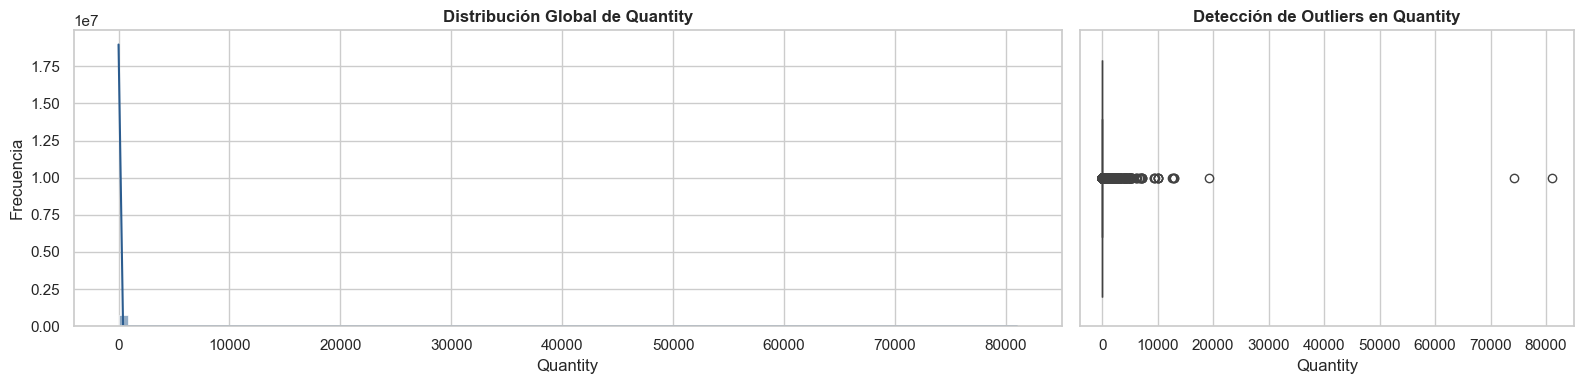

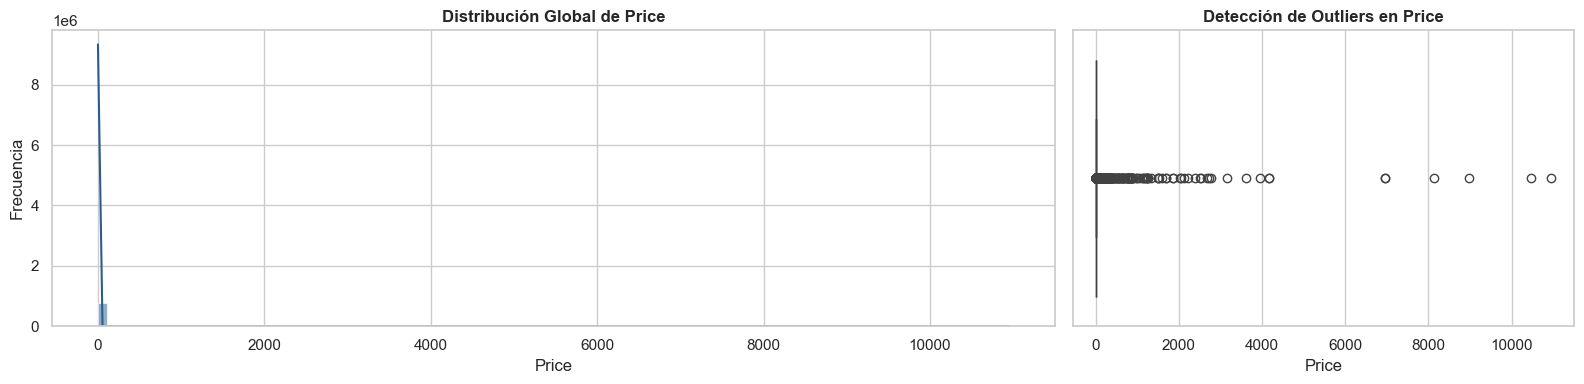


--- INICIANDO VISUALIZACIÓN DE COMPORTAMIENTOS Y CATEGORÍAS ---


C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='rocket')


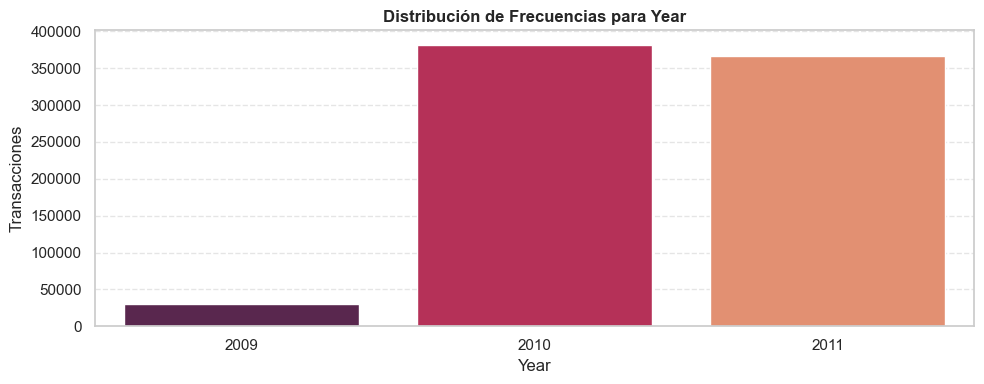

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


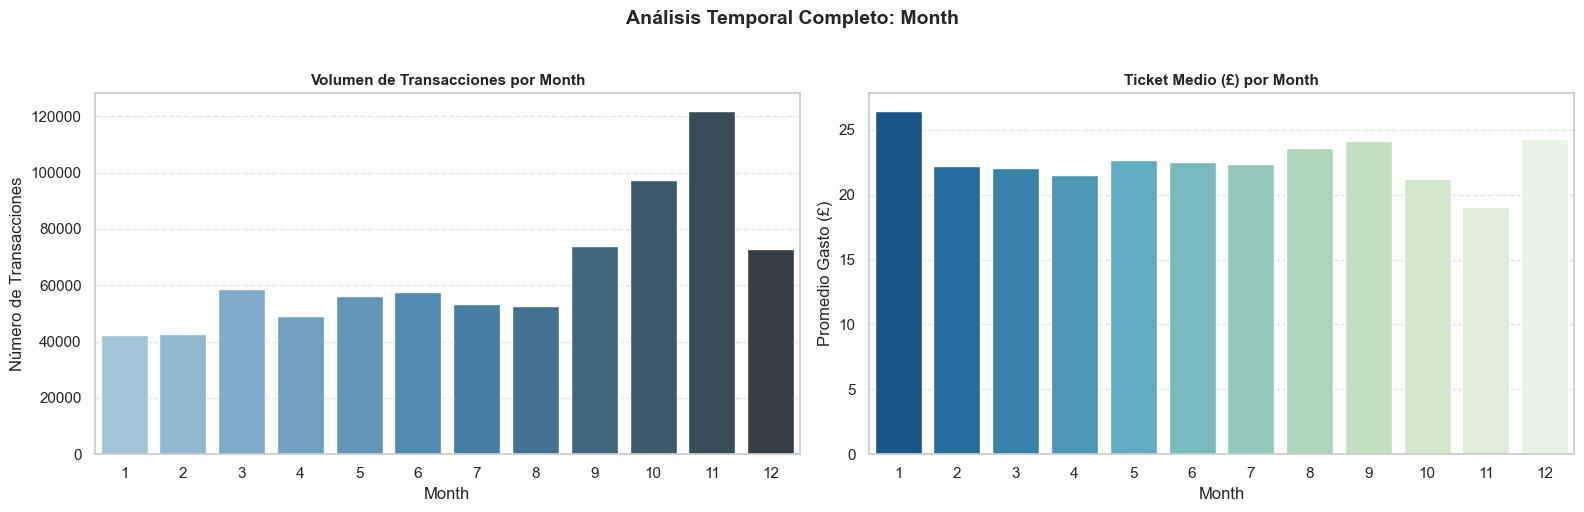

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


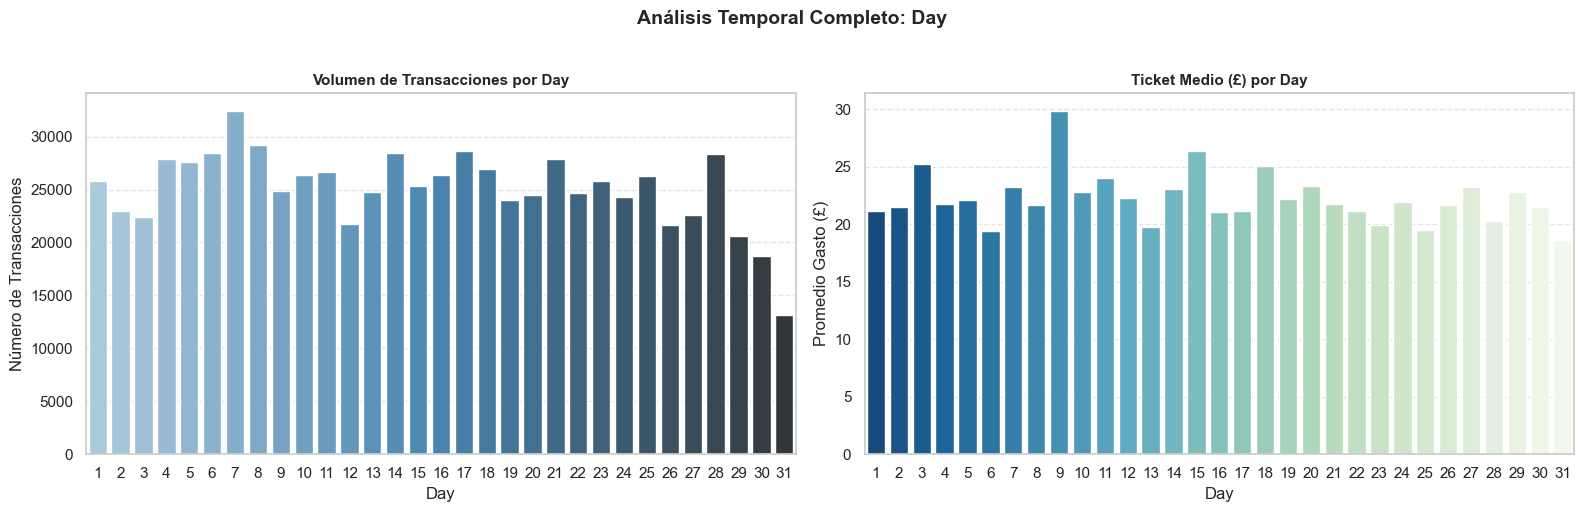

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


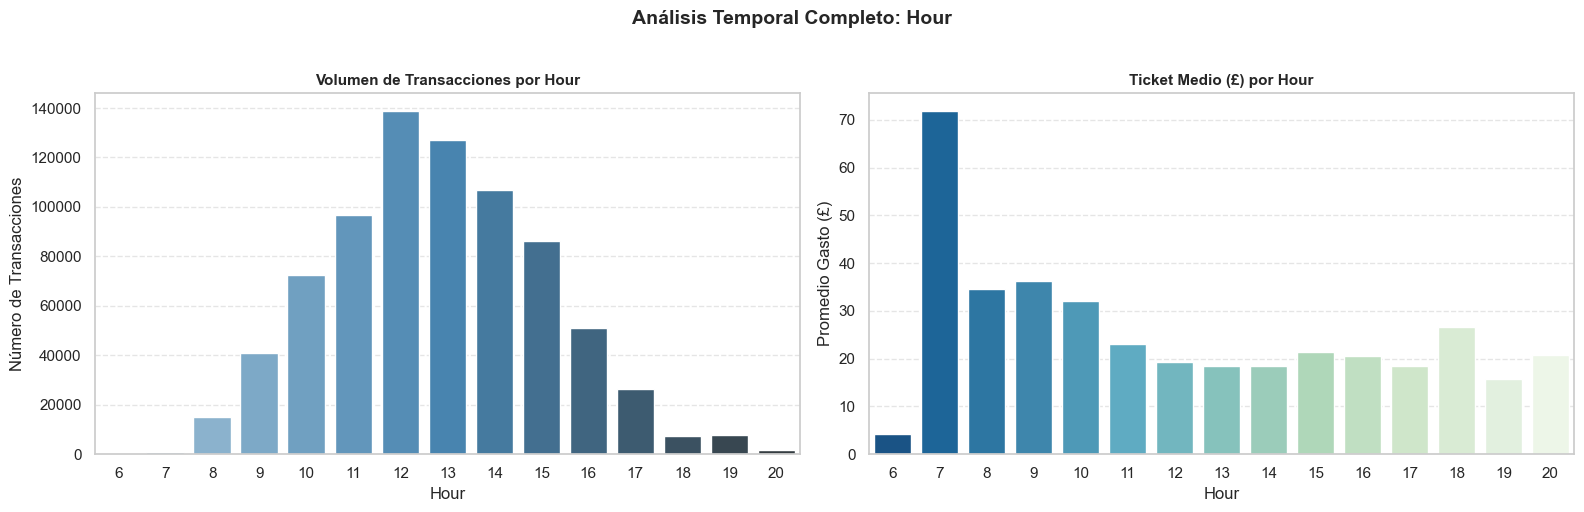

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


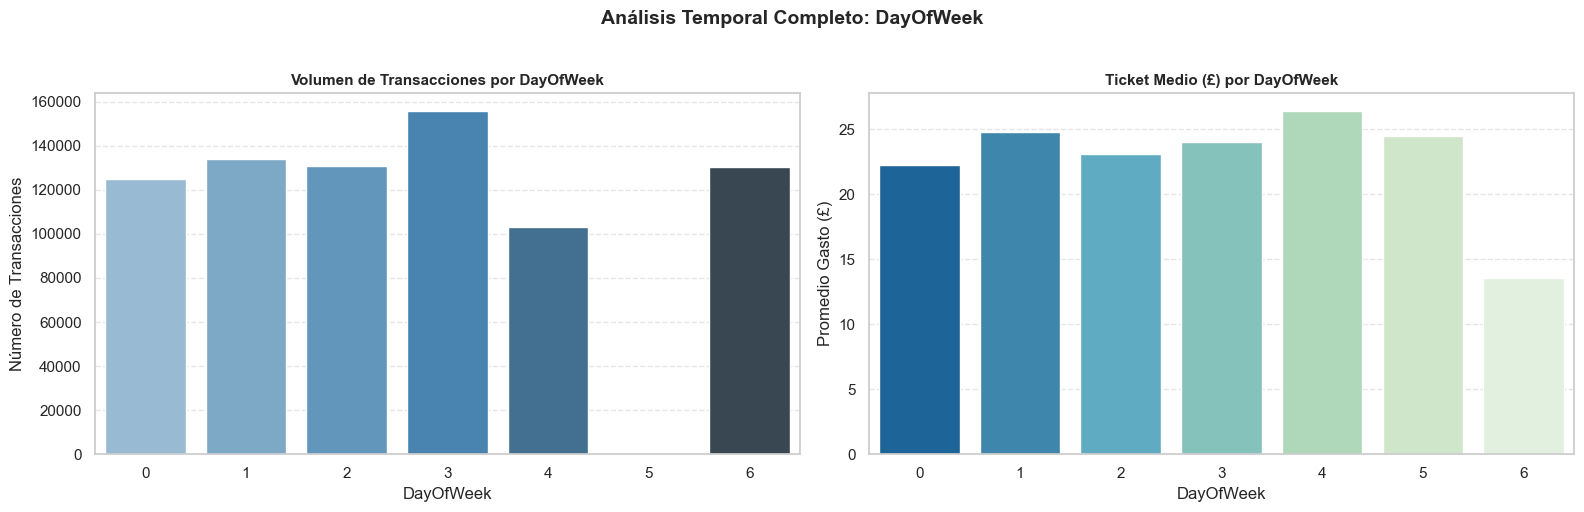

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_valores.values, y=top_valores.index.astype(str), palette='viridis')


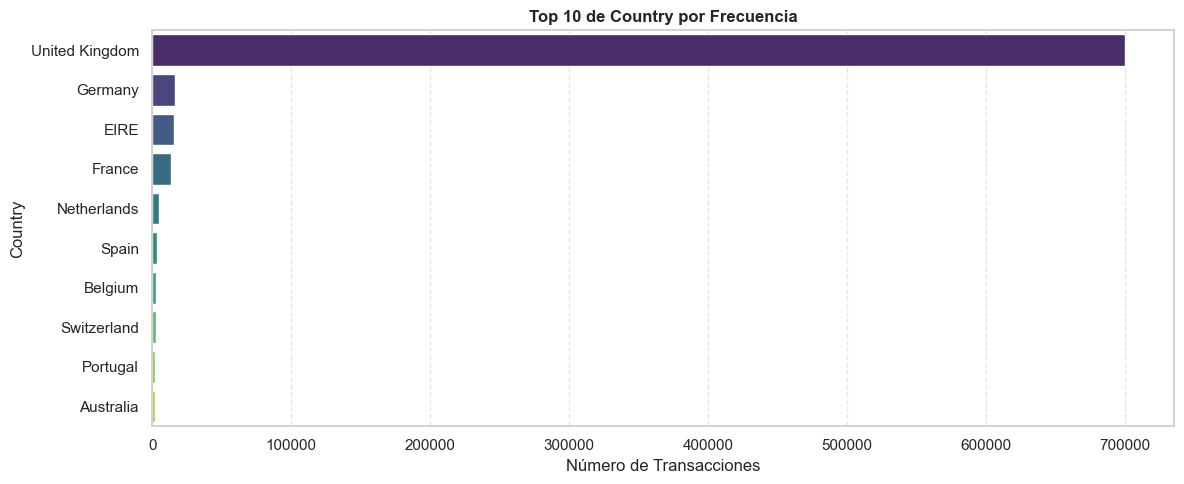

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_valores.values, y=top_valores.index.astype(str), palette='viridis')


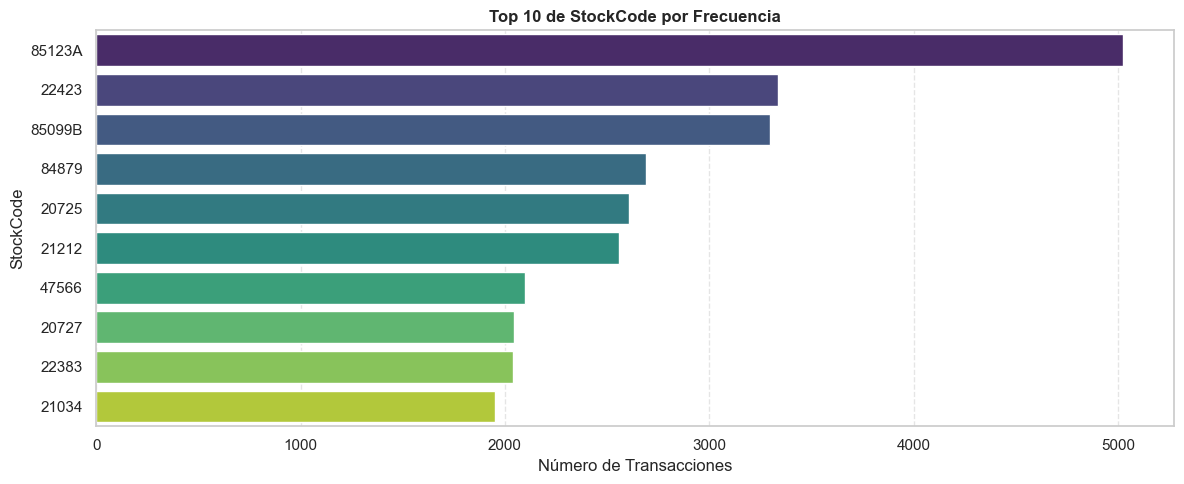

In [27]:
print("--- INICIANDO VISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS ---")
plot_metricas_distribucion(df, columnas_metricas)

print("\n--- INICIANDO VISUALIZACIÓN DE COMPORTAMIENTOS Y CATEGORÍAS ---")
plot_frecuencias_categorias(df, columnas_frecuencias, top_n=10)

## Manejo de Outliers

- Para el caso planteado, vamos a usar cuantiles para darle un criterio matemático y robusto a la hora dem manejar los outliers, como hemos podido ver en las gráficas, la mayor parte de los clientes no manejan los volúmenes que tienen los mayoristas.
Al hablar de tasa de Churn, es mejor centrarse en los clientes que no tienen cantidades tan altas para poder encontrar factores para poder fidelizar


--- DISTRIBUCIONES SIN OUTLIERS EXTREMOS ---


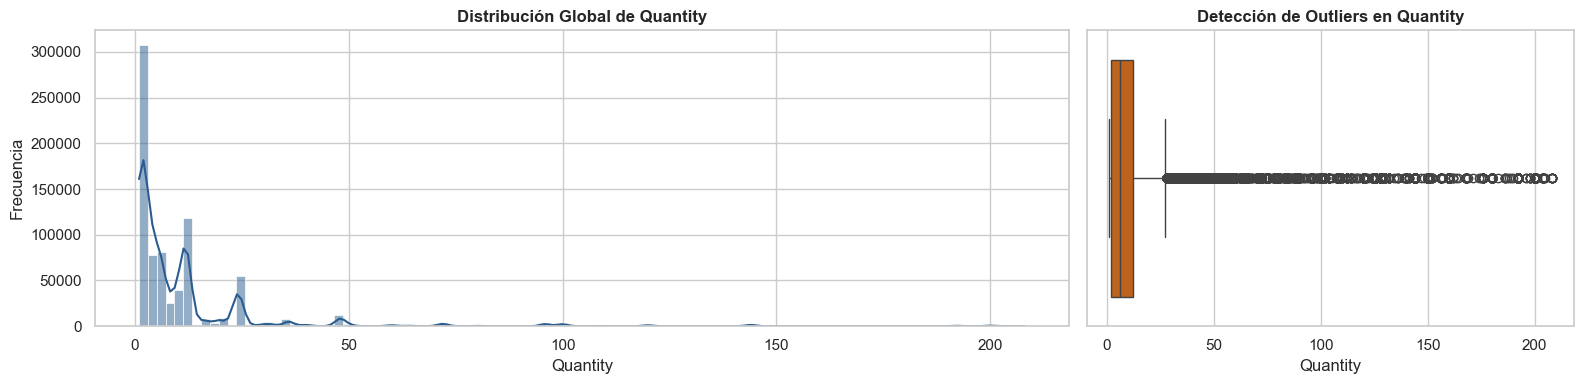

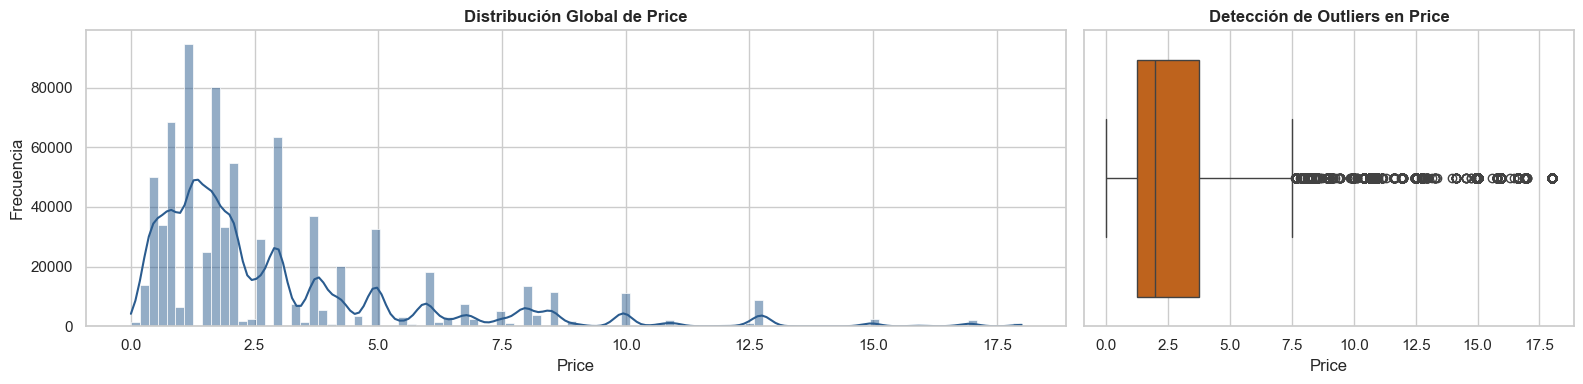

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='rocket')


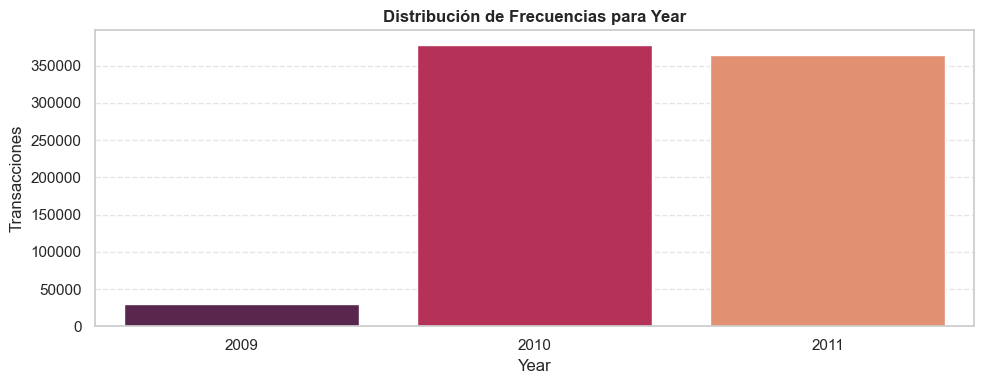

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


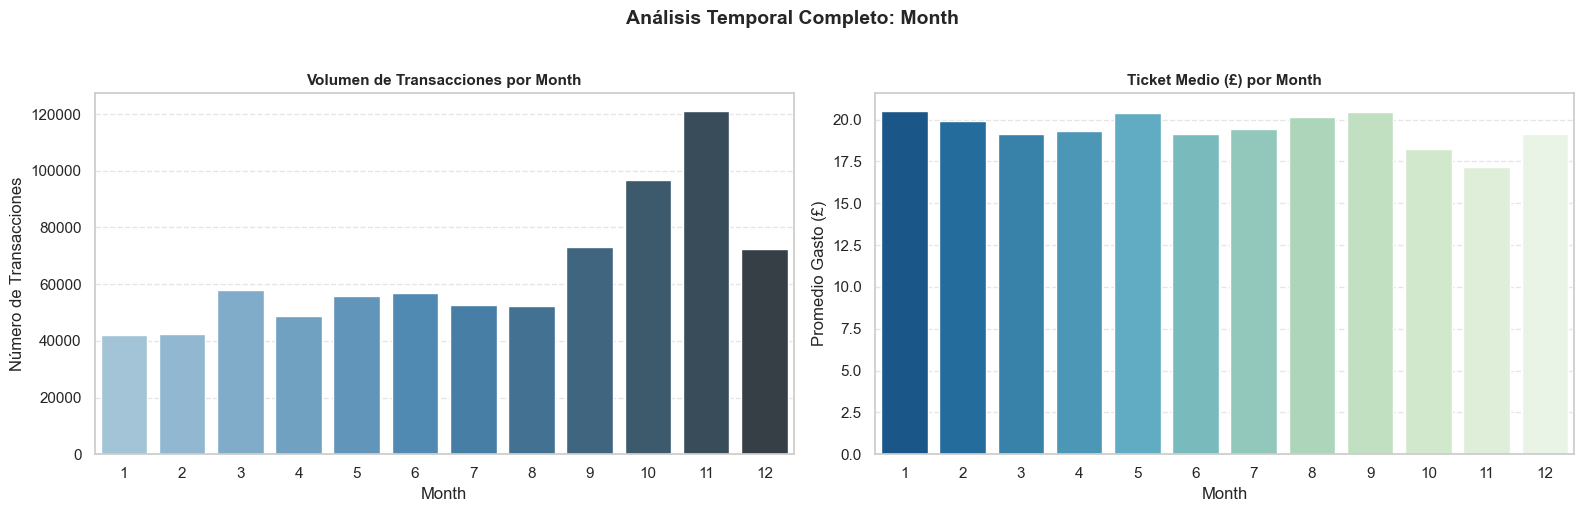

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


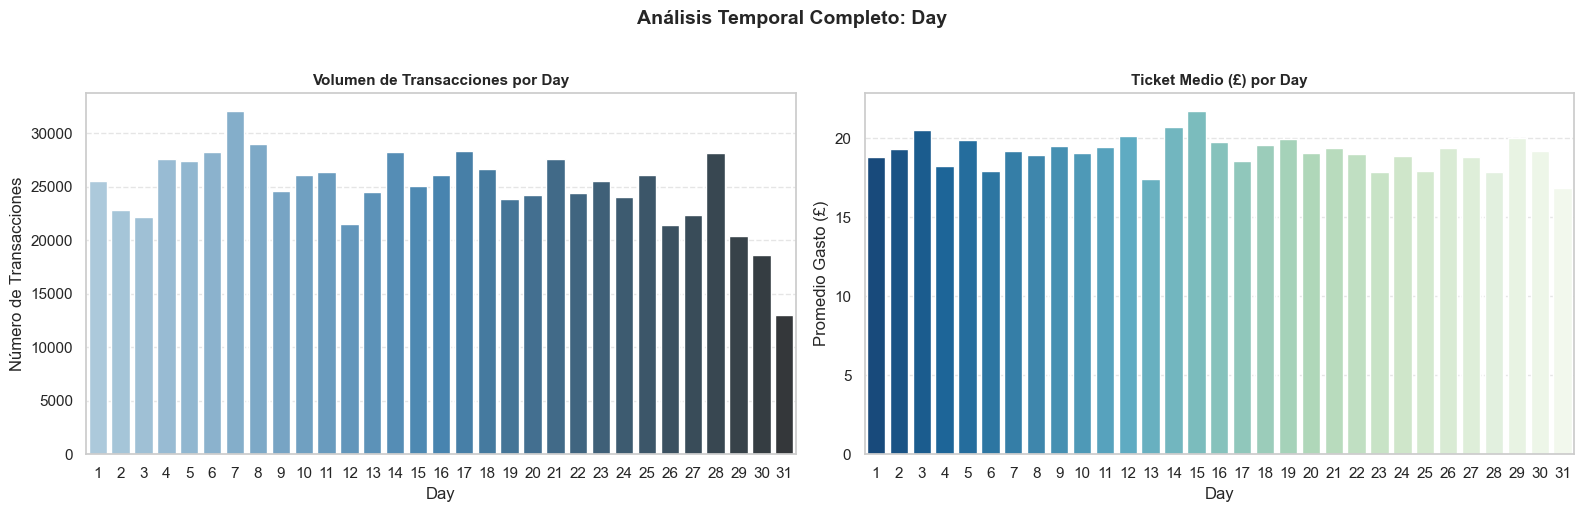

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


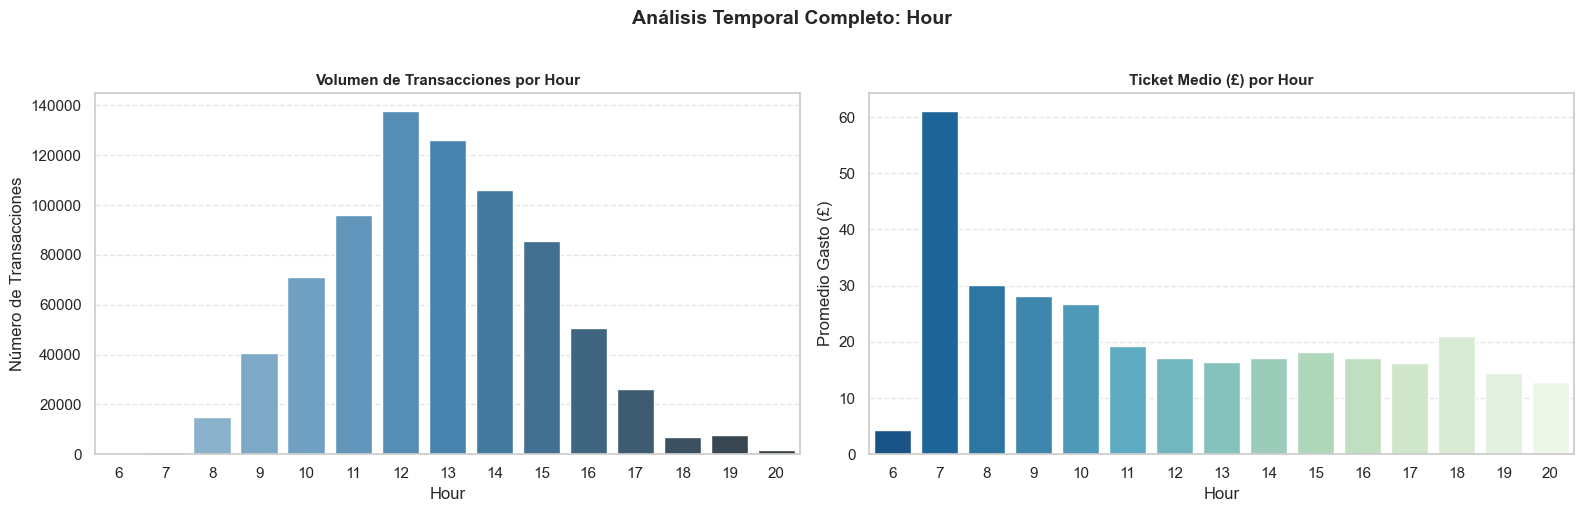

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteos.index, y=conteos.values, palette='Blues_d', ax=axes[0])
C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_temporal.index, y=media_temporal.values, palette='GnBu_r', ax=axes[1])


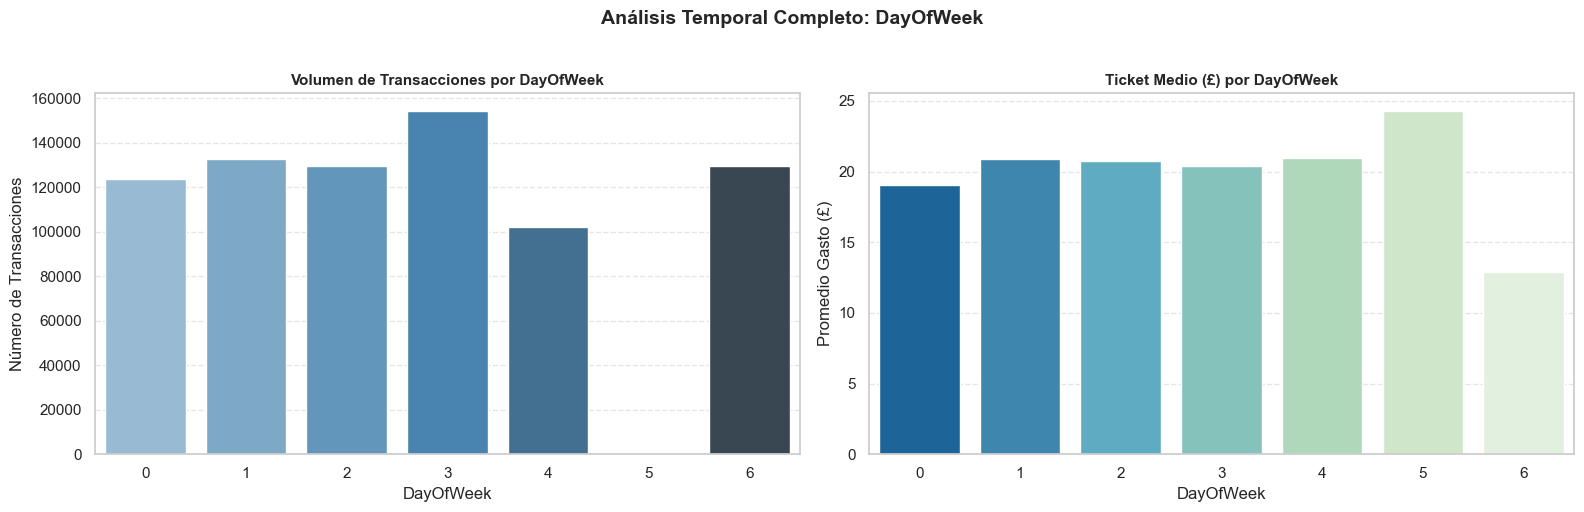

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_valores.values, y=top_valores.index.astype(str), palette='viridis')


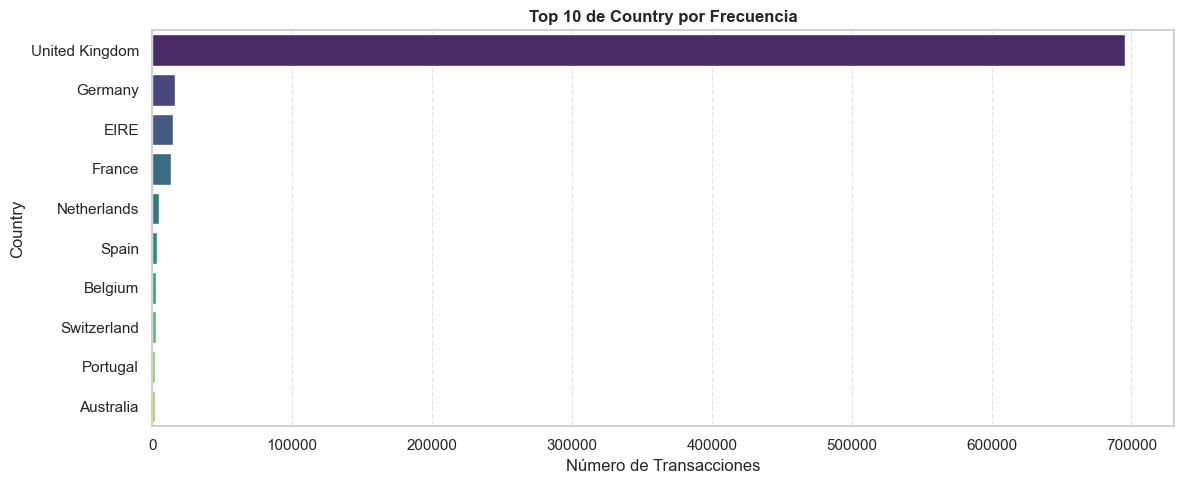

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\1545784305.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_valores.values, y=top_valores.index.astype(str), palette='viridis')


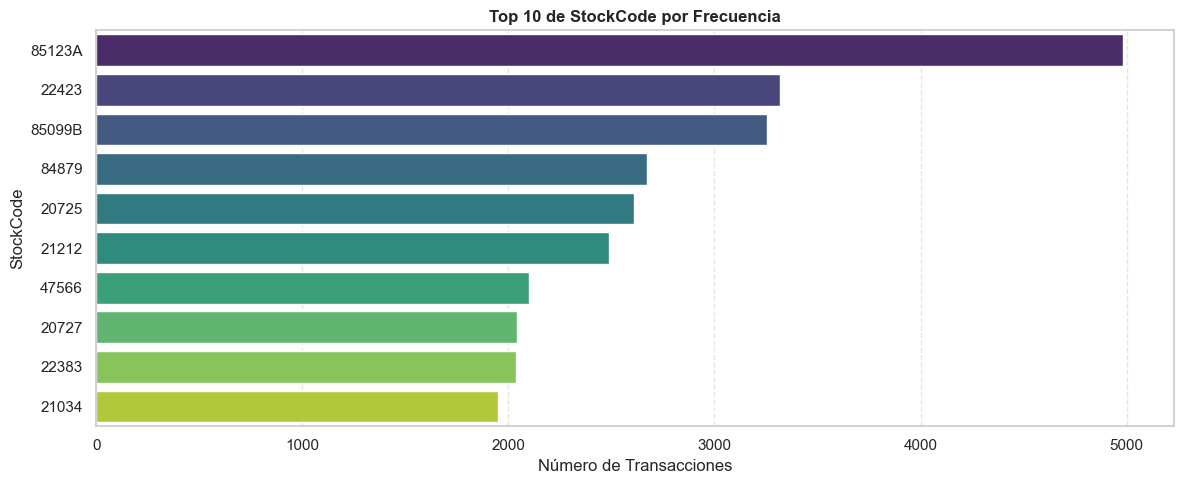

In [28]:
# Calculamos el percentil 99.5% para Quantity y Price
# Esto detecta de forma dinámica a partir de qué valor los datos se vuelven extremos y así no aplanamos las gráficas
umbral_quantity = df['Quantity'].quantile(0.995)
umbral_price = df['Price'].quantile(0.995)

# Aplicamos los sanity checks (mayores que cero) y de outliers (menores o iguales al cuantil)
df_visualizacion = df[
    (df['Quantity'] > 0) & (df['Quantity'] <= umbral_quantity) &
    (df['Price'] > 0) & (df['Price'] <= umbral_price)
].copy()


print("\n--- DISTRIBUCIONES SIN OUTLIERS EXTREMOS ---")
plot_metricas_distribucion(df_visualizacion, columnas_metricas)
plot_frecuencias_categorias(df_visualizacion, columnas_frecuencias, top_n=10)

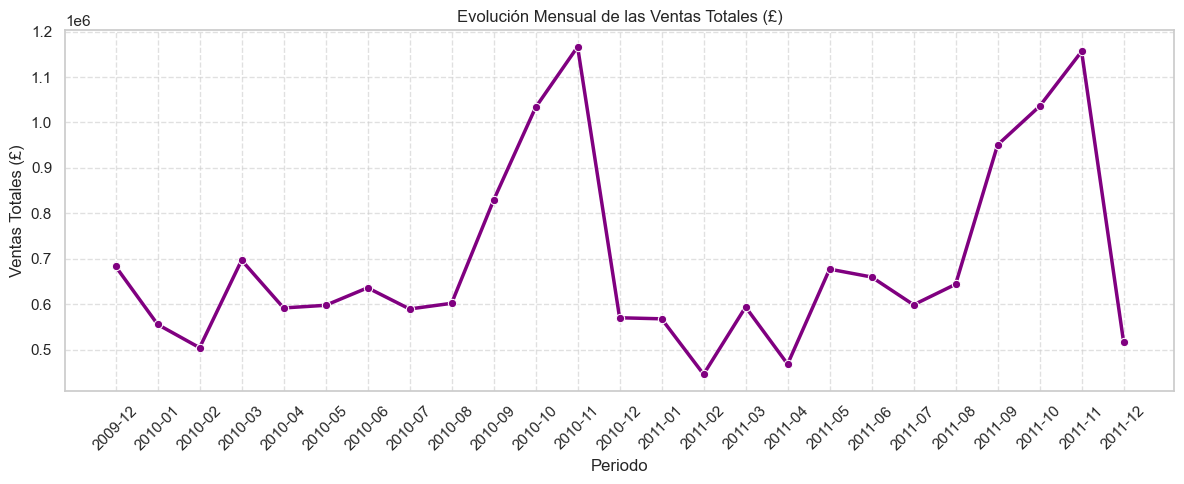

In [29]:
# Agrupar las ventas netas por Año y Mes
df_temporal = df.groupby(['Year', 'Month'])['TotalSales'].sum().reset_index()
df_temporal['Periodo'] = df_temporal['Year'].astype(str) + '-' + df_temporal['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_temporal, x='Periodo', y='TotalSales', marker='o', color='purple', linewidth=2.5)
plt.xticks(rotation=45)
plt.title('Evolución Mensual de las Ventas Totales (£)')
plt.ylabel('Ventas Totales (£)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [30]:
df[['StockCode', 'Description']].value_counts().sort_values(ascending=False).head(10)

StockCode  Description                       
85123A     WHITE HANGING HEART T-LIGHT HOLDER    5016
22423      REGENCY CAKESTAND 3 TIER              3335
84879      ASSORTED COLOUR BIRD ORNAMENT         2692
85099B     JUMBO BAG RED RETROSPOT               2641
47566      PARTY BUNTING                         2098
20727      LUNCH BAG  BLACK SKULL.               2045
21034      REX CASH+CARRY JUMBO SHOPPER          1950
22382      LUNCH BAG SPACEBOY DESIGN             1890
21232      STRAWBERRY CERAMIC TRINKET BOX        1859
21754      HOME BUILDING BLOCK WORD              1852
Name: count, dtype: int64

In [38]:
# Calculamos los umbrales (Percentil 99.5%)
limite_q_qty = df['Quantity'].quantile(0.995)
limite_q_prc = df['Price'].quantile(0.995)

print(f"Umbral estadístico de cantidad: {limite_q_qty}")
print(f"Umbral estadístico de precio: {limite_q_prc}")

# Filtramos (quitando también los menores o iguales a cero)
df_clean = df[(df['Quantity'] > 0) & (df['Quantity'] <= limite_q_qty)]
df_clean = df_clean[(df_clean['Price'] > 0) & (df_clean['Price'] <= limite_q_prc)]


Umbral estadístico de cantidad: 208.0
Umbral estadístico de precio: 18.0


## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [39]:

# Buscamos la fecha máxima del dataset para echar la vista atrás
fecha_maxima = df_clean['InvoiceDate'].max()

# Definimos los últimos 3 meses como "Ventana de Predicción" (Target)
fecha_corte = fecha_maxima - pd.DateOffset(months=3)

print(f"Fecha de inicio: {df_clean['InvoiceDate'].min()}")
print(f"Fecha de corte (división): {fecha_corte}")
print(f"Fecha final: {fecha_maxima}\n")

# Separamos el dataset
df_historico = df_clean[df_clean['InvoiceDate'] < fecha_corte].copy()
df_futuro = df_clean[df_clean['InvoiceDate'] >= fecha_corte].copy()

# =========================================================================

# Calculamos la venta total de cada línea en el histórico
df_historico['TotalSales'] = df_historico['Quantity'] * df_historico['Price']

# Agrupamos por cliente para extraer las métricas core
tablon_clientes = df_historico.groupby('Customer ID').agg(
    Facturacion_Total=('TotalSales', 'sum'),  # Suma de todos sus tickets (Monetario)
    Num_Compras=('Invoice', 'nunique'),   # Número de facturas distintas (Frequencia)
    Recencia=('InvoiceDate', lambda x: (fecha_corte - x.max()).days), # Recencia (días desde su última compra hasta el día de corte)
    Is_UK=('Country', lambda x: 1 if x.iloc[0] == 'United Kingdom' else 0)  # Nos quedamos con el país del cliente. Si es UK ponemos 1, si no, 0
).reset_index()


# Ticket medio 
tablon_clientes['Ticket_Medio'] = tablon_clientes['Facturacion_Total'] / tablon_clientes['Num_Compras']


# =========================================================================

# Identificamos qué clientes únicos compraron en la ventana del futuro
clientes_activos_futuro = df_futuro['Customer ID'].unique()

# Creamos la variable objetivo 'Target': 
# 1 si el ID del cliente aparece en el futuro, 0 si no aparece (Churn)
tablon_clientes['Target'] = tablon_clientes['Customer ID'].isin(clientes_activos_futuro).astype(int)


# =========================================================================

print("--- REPORTE DEL TABLÓN DE CLIENTES ---")
print(f"Total de clientes únicos para entrenar el modelo: {len(tablon_clientes)}")
print(f"Clientes que SÍ volvieron a comprar (Clase 1): {tablon_clientes['Target'].sum()}")
print(f"Clientes que NO volvieron (Clase 0): {len(tablon_clientes) - tablon_clientes['Target'].sum()}")
print(f"Porcentaje de recompra (Ratio de Balanceo): {(tablon_clientes['Target'].mean()) * 100:.2f}%")

tablon_clientes.head()

Fecha de inicio: 2009-12-01 07:45:00
Fecha de corte (división): 2011-09-09 12:50:00
Fecha final: 2011-12-09 12:50:00

--- REPORTE DEL TABLÓN DE CLIENTES ---
Total de clientes únicos para entrenar el modelo: 5221
Clientes que SÍ volvieron a comprar (Clase 1): 2276
Clientes que NO volvieron (Clase 0): 2945
Porcentaje de recompra (Ratio de Balanceo): 43.59%


,Customer ID,Facturacion_Total,Num_Compras,Recencia,Is_UK,Ticket_Medio,Target
0,12346.0,372.86,11,437,1,33.896364,0
1,12347.0,3152.79,6,38,0,525.465000,1
2,12348.0,1389.40,4,157,0,347.350000,1
3,12349.0,2081.34,2,316,0,1040.670000,1
4,12350.0,294.40,1,218,0,294.400000,0


## Matriz de Correlaciones

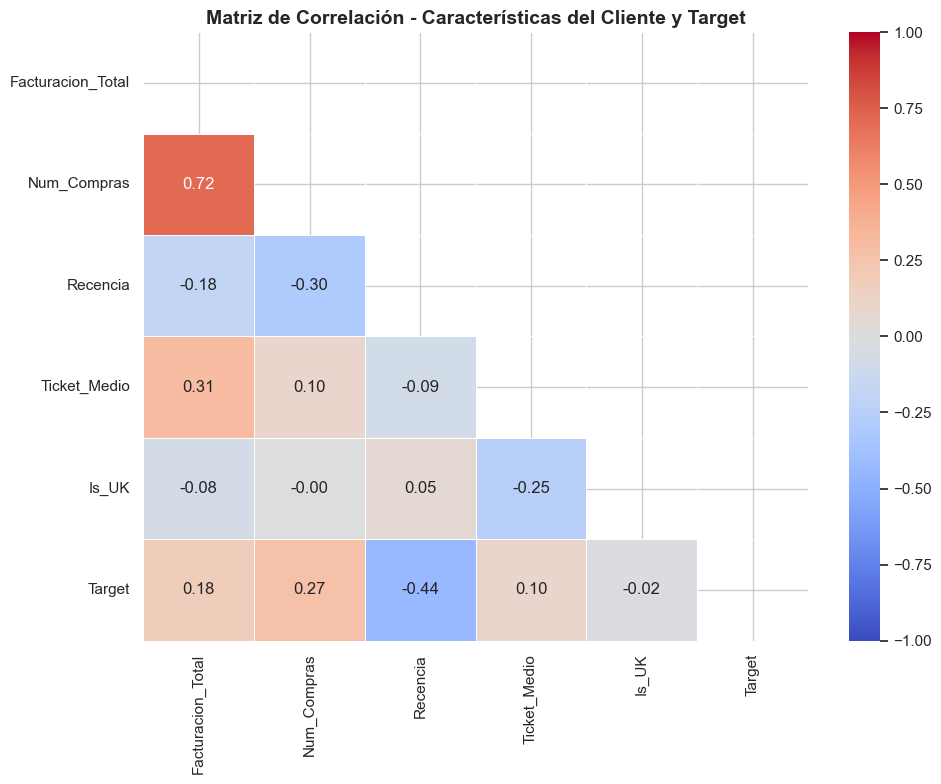

In [42]:
columnas_analisis = ['Facturacion_Total', 'Num_Compras', 'Recencia', 'Ticket_Medio', 'Is_UK', 'Target']
matriz_corr = tablon_clientes[columnas_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True,       
    cmap='coolwarm',     
    fmt=".2f",        
    linewidths=0.5,   
    vmin=-1, vmax=1,
    mask=np.triu(np.ones_like(matriz_corr, dtype=bool))
)

plt.title('Matriz de Correlación - Características del Cliente y Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Check de balanceo de datos

C:\Users\jesus\AppData\Local\Temp\ipykernel_28832\2874810334.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=tablon_clientes, x='Target',palette=['#4a90e2', '#2ecc71'])


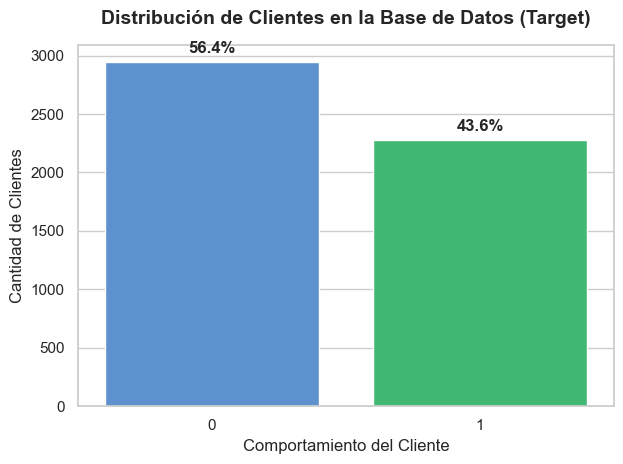

In [43]:
ax = sns.countplot(data=tablon_clientes, x='Target',palette=['#4a90e2', '#2ecc71'])

total = len(tablon_clientes['Target'])
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + (total * 0.01) # Un pequeño margen hacia arriba
    ax.annotate(porcentaje, (x_pos, y_pos), ha='center', va='bottom', fontsize=12, fontweight='bold')
    
plt.title('Distribución de Clientes en la Base de Datos (Target)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Comportamiento del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, cohen_kappa_score, matthews_corrcoef

features = ['Facturacion_Total', 'Num_Compras', 'Recencia', 'Ticket_Medio', 'Is_UK']
X = tablon_clientes[features]
y = tablon_clientes['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# StandardScaler seleccionado por la sensibilidad a outliers del min-max
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Grid de modelos
models = {
    'Reg Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Reg Logística Ridge (L2)': LogisticRegression(penalty='l2', C=0.1, random_state=42, max_iter=1000),
    'Reg Logística Lasso (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000),
    'Reg Logística Balanceada': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Logística Balanceada + Ridge': LogisticRegression(class_weight='balanced', penalty='l2', C=0.1, random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'SVM (RBF Kernel)': SVC(probability=True, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=200, depth=4, learning_rate=0.05, random_state=42, verbose=0)
}

# Evaluaciones
plt.figure(figsize=(10, 8))
resultados_metricas = []
matrices_confusion = {}
curvas_roc = {}

print("--- EVALUANDO EL DICCIONARIO DE MODELOS ---")

for nombre, modelo in models.items():
    # Entrenar
    modelo.fit(X_train_scaled, y_train)
    
    # Predecir probabilidades (AUC) de la clase 1 (Recompra) y de clase (Kappa, MCC, Matriz)
    y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    y_pred_clase = modelo.predict(X_test_scaled)
    
    # Cálculo de métricas
    auc = roc_auc_score(y_test, y_pred_proba)
    kappa = cohen_kappa_score(y_test, y_pred_clase)
    mcc = matthews_corrcoef(y_test, y_pred_clase)
    matriz = confusion_matrix(y_test, y_pred_clase)
    
    # Guardamos métricas
    matrices_confusion[nombre] = matriz
    curvas_roc[nombre] = (roc_curve(y_test, y_pred_proba), auc)
    
    resultados_metricas.append({
        'Modelo': nombre,
        'AUC Score': round(auc, 4),
        'Kappa de Cohen': round(kappa, 4),
        'Corr. Matthews (MCC)': round(mcc, 4)
    })
    
# Convertimos a DataFrame para ordenarlo por la métrica (AUC)
df_resultados = pd.DataFrame(resultados_metricas).sort_values(by='AUC Score', ascending=False)
print("\n==================================================================")
print("             TABLA COMPARATIVA DE MÉTRICAS                  ")
print("==================================================================")
df_resultados.reset_index(drop=True)

--- EVALUANDO EL DICCIONARIO DE MODELOS ---


c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Incon


             TABLA COMPARATIVA DE MÉTRICAS                  


,Modelo,AUC Score,Kappa de Cohen,Corr. Matthews (MCC)
0,CatBoost,0.8076,0.4357,0.4372
1,Random Forest,0.8061,0.4417,0.4418
2,XGBoost,0.8010,0.4333,0.4351
3,LightGBM,0.7990,0.4261,0.4286
4,Reg Logística Balanceada,0.7983,0.4064,0.4083
5,Reg Logística,0.7981,0.4186,0.4191
6,Reg Logística Lasso (L1),0.7979,0.4096,0.4099
7,Logística Balanceada + Ridge,0.7977,0.4046,0.4066
8,Reg Logística Ridge (L2),0.7975,0.4072,0.4076
9,Decision Tree,0.7922,0.4499,0.4505


<Figure size 1000x800 with 0 Axes>

In [45]:
df_resultados.to_pickle('resultado_modelos.pkl')

--- GENERANDO 13 PANELES DE CURVAS ROC INDIVIDUALES (5x3) ---


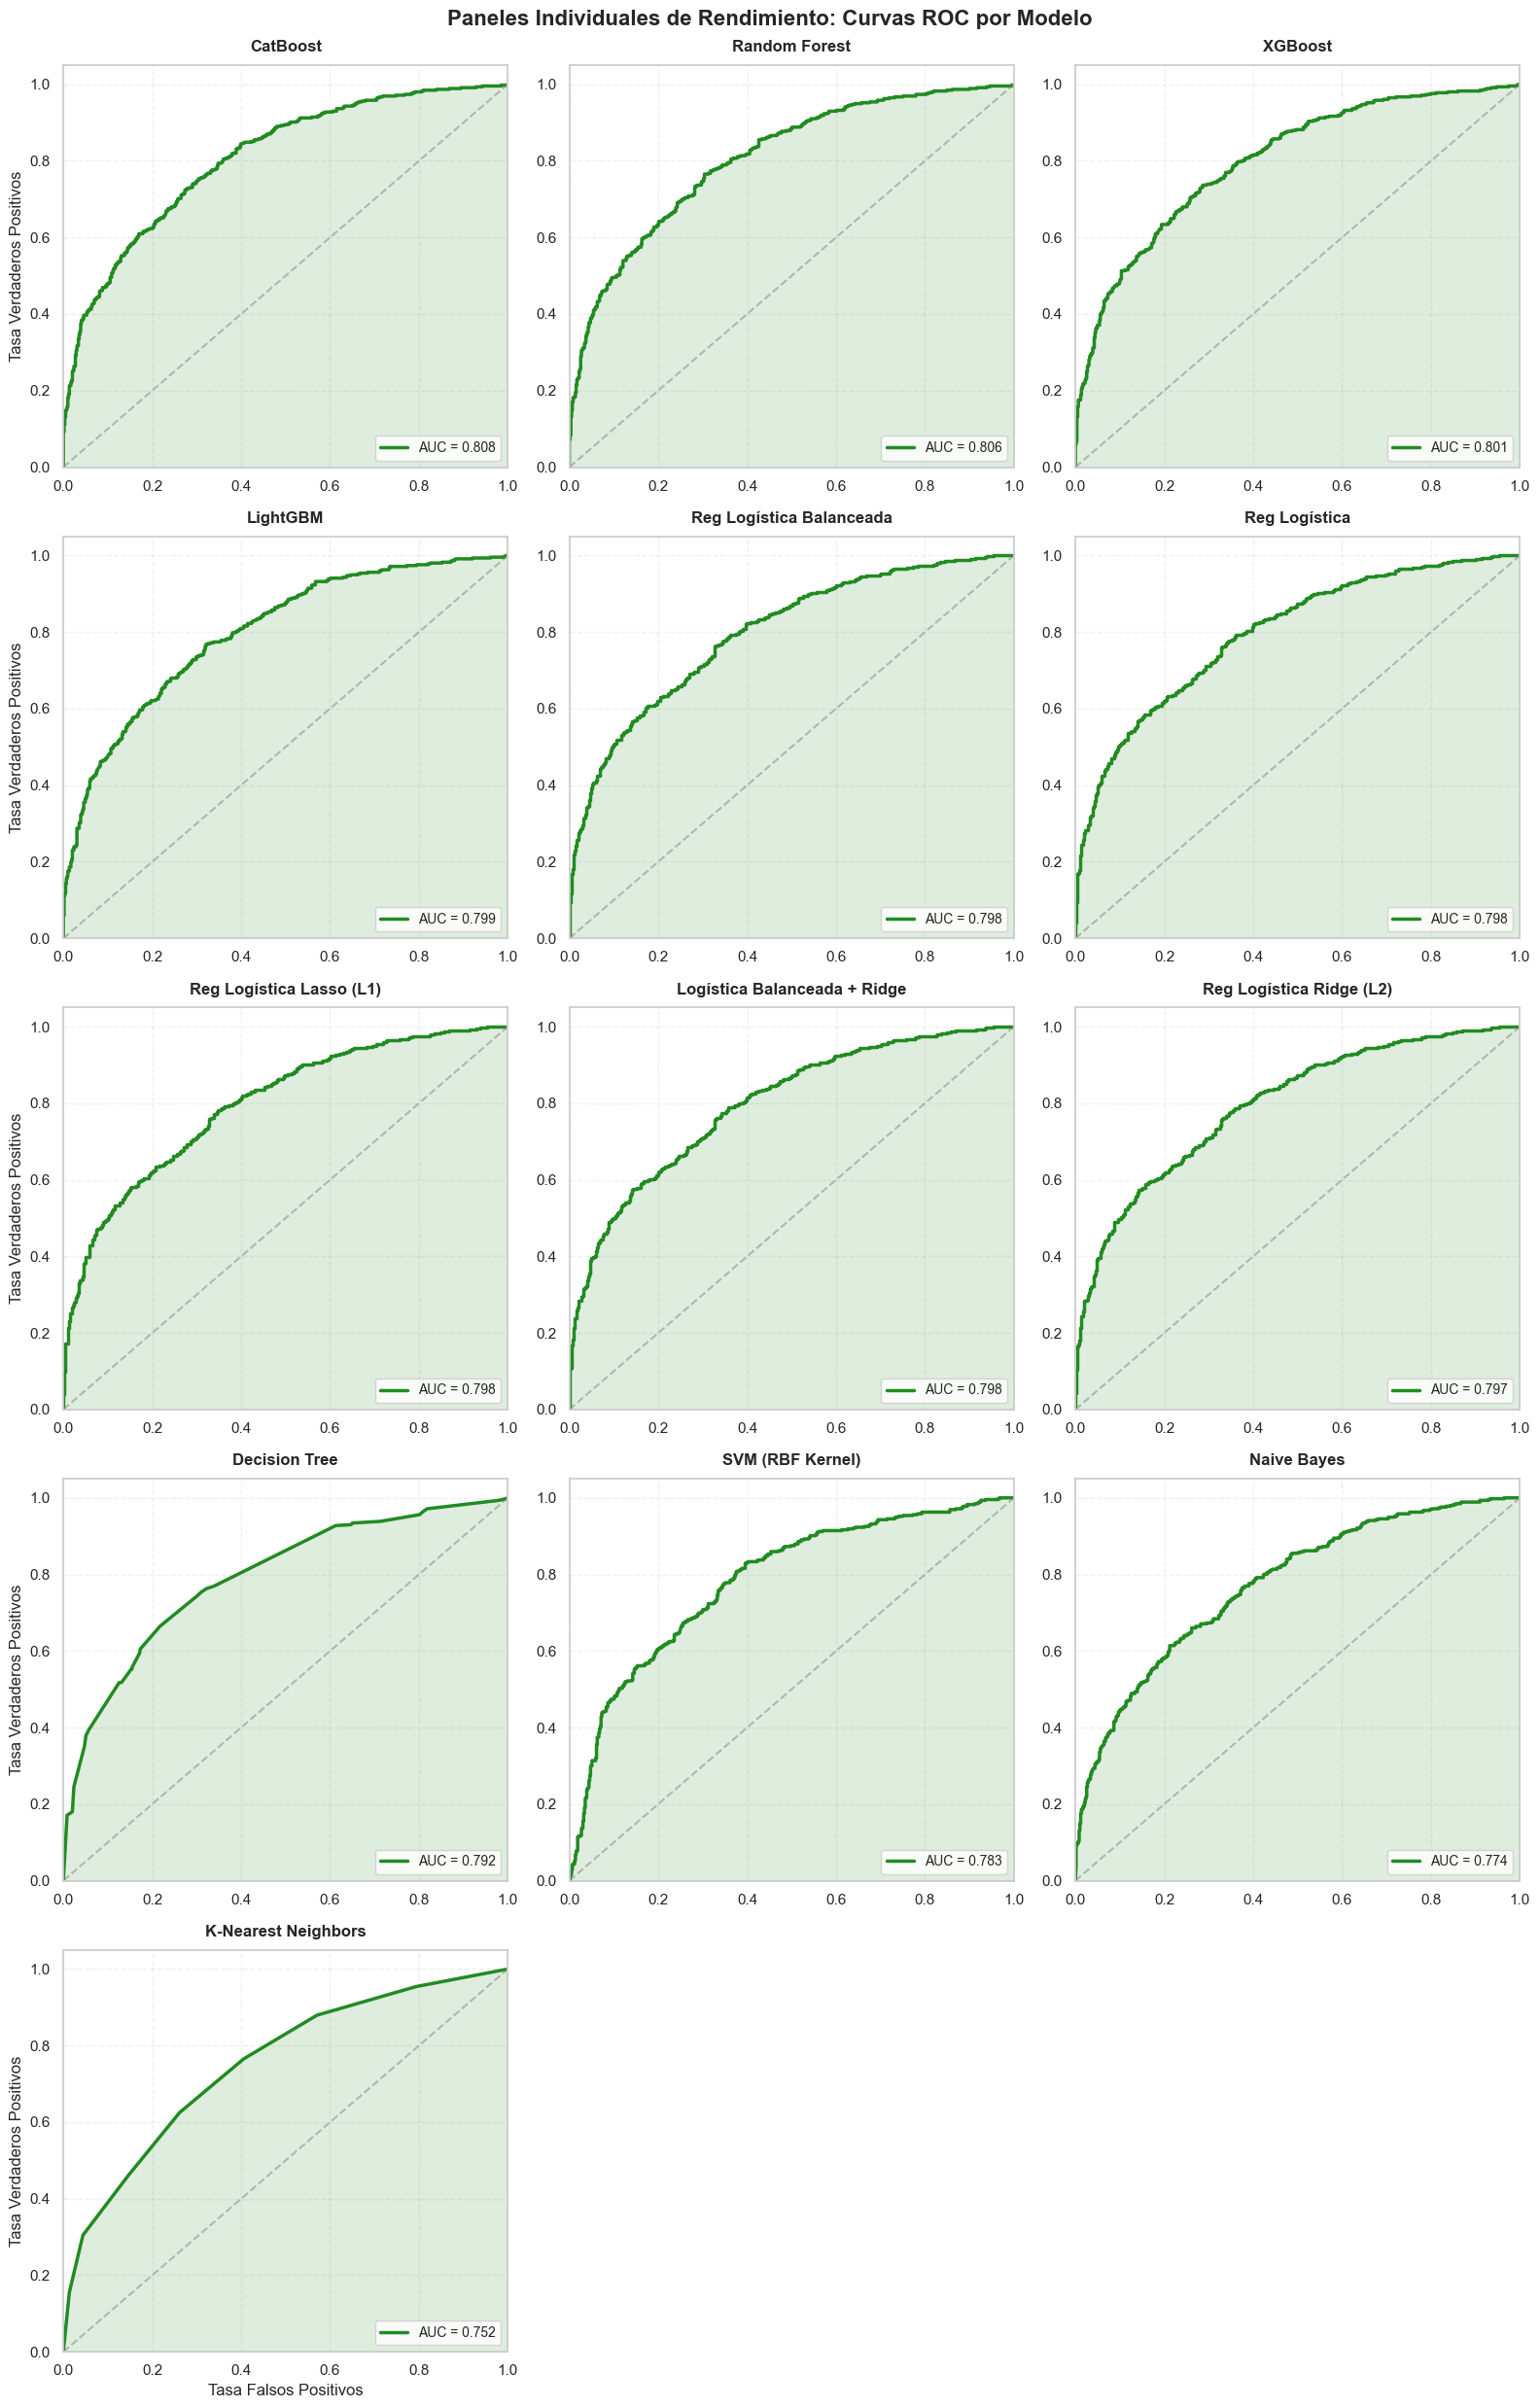

In [46]:
import math

modelos_ordenados = df_resultados['Modelo'].tolist()
num_modelos = len(modelos_ordenados)

# Calculamos cuántas filas necesitamos
columnas = 3
filas = math.ceil(num_modelos / columnas) 

# Creamos el lienzo con el tamaño adaptado
fig, axes = plt.subplots(filas, columnas, figsize=(16, 5 * filas))
axes = axes.ravel() # Aplanamos la matriz de gráficos a una lista de 1 dimensión

print(f"--- GENERANDO {num_modelos} PANELES DE CURVAS ROC INDIVIDUALES ({filas}x{columnas}) ---")

for i, nombre in enumerate(modelos_ordenados):
    # Extraemos los datos de la curva ROC previamente calculados
    datos_roc, auc_score = curvas_roc[nombre]
    fpr, tpr, _ = datos_roc
    
    # Dibujamos en el subgráfico correspondiente (aquí ya nunca se romperá el índice)
    axes[i].plot(fpr, tpr, color='forestgreen', lw=2.5, label=f'AUC = {auc_score:.3f}')
    axes[i].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5) # Diagonal de referencia
    
    # Rellenamos el área bajo la curva con un color suave
    axes[i].fill_between(fpr, tpr, alpha=0.15, color='forestgreen')
    
    # Configuración de estética e información de cada cuadro
    axes[i].set_title(f'{nombre}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    
    # Colocamos las etiquetas de los ejes de forma inteligente según la posición
    if i >= (filas - 1) * columnas: # Última fila real con datos
        axes[i].set_xlabel('Tasa Falsos Positivos')
    if i % columnas == 0: # Primera columna de cada fila
        axes[i].set_ylabel('Tasa Verdaderos Positivos')
        
    axes[i].legend(loc="lower right", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.3)

# Si quedan cuadros vacíos al final, los ocultamos
for j in range(num_modelos, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Paneles Individuales de Rendimiento: Curvas ROC por Modelo', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


In [47]:
import optuna
from catboost import CatBoostClassifier
import logging

# Desactivamos los mensajes largos de Optuna 
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo(trial):
    # Definimos los rangos de hiperparámetros que Optuna va a explorar
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed': 42,
        'verbose': 0
    }
    
    # Entrenamos el modelo con los parámetros de esta prueba (trial)
    modelo_opt = CatBoostClassifier(**param)
    modelo_opt.fit(X_train_scaled, y_train)
    
    # Predecimos y evaluamos con el AUC de Test
    preds = modelo_opt.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    return auc

# Iniciamos la optimización buscando maximizar el AUC
print("--- INICIANDO OPTIMIZACIÓN CON OPTUNA (BUSCANDO EL MEJOR AUC) ---")
study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=200) 

print("\n==================================================================")
print(f" 🎯 ¡MEJORES PARÁMETROS ENCONTRADOS POR OPTUNA!")
print("==================================================================")
print(study.best_params)
print(f"-> AUC Máximo alcanzado: {study.best_value:.4f}")

c:\Users\jesus\OneDrive\Documents\Evolve Data Science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- INICIANDO OPTIMIZACIÓN CON OPTUNA (BUSCANDO EL MEJOR AUC) ---

 🎯 ¡MEJORES PARÁMETROS ENCONTRADOS POR OPTUNA!
{'iterations': 107, 'depth': 4, 'learning_rate': 0.03849734374687254, 'l2_leaf_reg': 0.001353197773229628}
-> AUC Máximo alcanzado: 0.8095


In [48]:
best_params = study.best_params
best_model = CatBoostClassifier(**best_params)
best_model.fit(X_train, y_train)
catbost_pred  = best_model.predict(X_test)
catboost_pred_proba = best_model.predict_proba(X_test)[:, 1]

0:	learn: 0.6841945	total: 749us	remaining: 79.5ms
1:	learn: 0.6750108	total: 1.51ms	remaining: 79.1ms
2:	learn: 0.6672677	total: 2.21ms	remaining: 76.6ms
3:	learn: 0.6598912	total: 2.88ms	remaining: 74.1ms
4:	learn: 0.6529839	total: 3.58ms	remaining: 73ms
5:	learn: 0.6463655	total: 4.42ms	remaining: 74.5ms
6:	learn: 0.6403534	total: 5.32ms	remaining: 76.1ms
7:	learn: 0.6347888	total: 6.06ms	remaining: 75ms
8:	learn: 0.6291331	total: 6.82ms	remaining: 74.3ms
9:	learn: 0.6239724	total: 7.5ms	remaining: 72.8ms
10:	learn: 0.6194908	total: 8.18ms	remaining: 71.3ms
11:	learn: 0.6149694	total: 8.81ms	remaining: 69.8ms
12:	learn: 0.6105141	total: 9.48ms	remaining: 68.5ms
13:	learn: 0.6064273	total: 10.1ms	remaining: 67.3ms
14:	learn: 0.6025158	total: 10.8ms	remaining: 66.2ms
15:	learn: 0.5987432	total: 11.4ms	remaining: 65.1ms
16:	learn: 0.5952833	total: 12.1ms	remaining: 64.2ms
17:	learn: 0.5922774	total: 12.8ms	remaining: 63.2ms
18:	learn: 0.5893290	total: 13.4ms	remaining: 62.3ms
19:	learn

           REPORTE DE CLASIFICACIÓN (MÉTRICAS BASE)               
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       589
           1       0.71      0.64      0.67       456

    accuracy                           0.73      1045
   macro avg       0.73      0.72      0.72      1045
weighted avg       0.73      0.73      0.73      1045



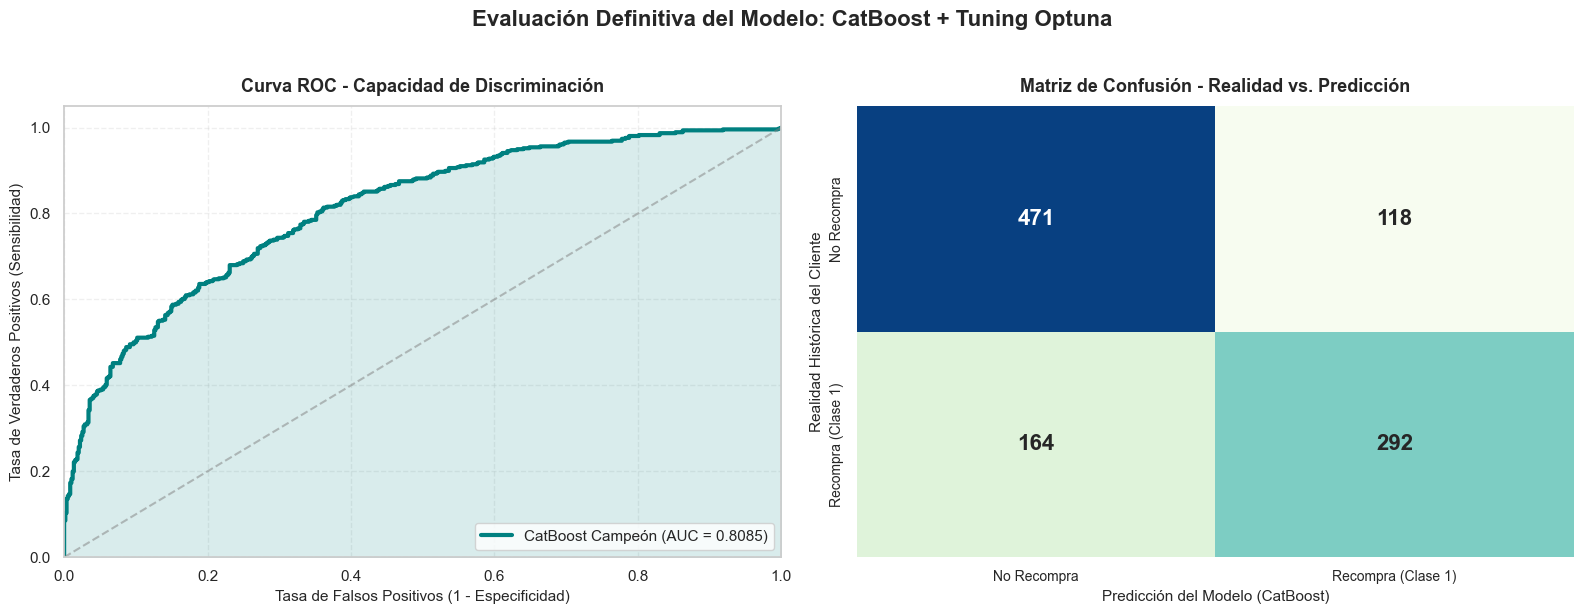

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, cohen_kappa_score, matthews_corrcoef, classification_report



fpr, tpr, threshholds = roc_curve(y_test, catboost_pred_proba)
auc_score = roc_auc_score(y_test, catboost_pred_proba)

cm = confusion_matrix(y_test, catbost_pred)
kappa = cohen_kappa_score(y_test, catbost_pred)
mcc = matthews_corrcoef(y_test, catbost_pred)
report = classification_report(y_test, catbost_pred)

print("==================================================================")
print("           REPORTE DE CLASIFICACIÓN (MÉTRICAS BASE)               ")
print("==================================================================")
print(report)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO DE LA IZQUIERDA: CURVA ROC DEFINITIVA ---
axes[0].plot(fpr, tpr, color='teal', lw=3, label=f'CatBoost Campeón (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5) # Diagonal de referencia
axes[0].fill_between(fpr, tpr, alpha=0.15, color='teal') # Relleno suave del área

axes[0].set_title('Curva ROC - Capacidad de Discriminación', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)


# --- GRÁFICO DE LA DERECHA: MATRIZ DE CONFUSIÓN ENFOCADA A NEGOCIO ---
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='GnBu', 
    cbar=False, 
    ax=axes[1], 
    annot_kws={'size': 16, 'weight': 'bold'}
)

axes[1].set_title('Matriz de Confusión - Realidad vs. Predicción', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicción del Modelo (CatBoost)', fontsize=11)
axes[1].set_ylabel('Realidad Histórica del Cliente', fontsize=11)
axes[1].set_xticklabels(['No Recompra', 'Recompra (Clase 1)'], fontsize=10)
axes[1].set_yticklabels(['No Recompra', 'Recompra (Clase 1)'], fontsize=10)


plt.suptitle('Evaluación Definitiva del Modelo: CatBoost + Tuning Optuna', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [ ]:
vis.plot_param_importances(study)

## Guardamos el modelo para poder cargarlo de forma directa

In [52]:
CatBoost_model = {
    # El Modelo y sus parámetros
    'modelo_catboost': best_model,
    'parametros_optuna': best_params,
    
    # Predicciones crudas
    'predicciones_clase': catbost_pred,
    'predicciones_probabilidad': catboost_pred_proba,
    
    # Pack de Métricas Precalculadas
    'metricas': {
        'auc_score': auc_score,
        'roc_curva_fpr': fpr,
        'roc_curva_tpr': tpr,
        'matriz_confusion': cm,
        'kappa_cohen': kappa,
        'coeficiente_mcc': mcc,
        'classification_report_txt': report
    }
}

with open("CatBoost_model.pkl", 'wb') as archivo:
    pickle.dump(CatBoost_model, archivo)

## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()



In [53]:
import dalex as dx

# Creamos el explainer
exp_catboost = dx.Explainer(
    model=best_model, 
    data=X_test, 
    y=y_test,
    label="CatBoost Optimizado",
    verbose=False
)

print("--- GENERANDO ANÁLISIS GLOBAL CON DALEX ---")

# Importancia por Permutación (Mide el impacto real en el AUC)
importancia_global = exp_catboost.model_parts()

importancia_global.plot(title='Importancia Global de Variables (Pérdida de AUC - DALEX)')


# Perfil de Respuesta Promedio (PDP) para la Recencia
# Muestra la curva exacta de cómo afecta la inactividad a la probabilidad
pdp_recencia = exp_catboost.model_profile(variables=['Recencia'])

pdp_recencia.plot(title='Efecto Marginal de los Días de Inactividad (Recencia) en la Recompra')


print("\n--- GENERANDO ANÁLISIS LOCAL CON DALEX ---")

# Tomamos el primer cliente de la lista de pruebas como ejemplo
cliente_ejemplo = X_test.iloc[[0]]
prob_estimada = catboost_pred_proba[0]

print(f"-> Analizando Cliente de Ejemplo:")
print(f"   • Recencia: {cliente_ejemplo['Recencia'].values[0]} días sin comprar.")
print(f"   • Num. Compras: {cliente_ejemplo['Num_Compras'].values[0]} transacciones.")
print(f"   • Facturación Total: £{cliente_ejemplo['Facturacion_Total'].values[0]:.2f}")
print(f"-> Probabilidad de Recompra calculada: {prob_estimada:.2%}\n")

# Gráfico Break-Down (Aporte secuencial de variables)
bd_cliente = exp_catboost.predict_parts(cliente_ejemplo, type='break_down')

bd_cliente.plot(title=f'Desglose de Predicción (Break-Down) | Probabilidad: {prob_estimada:.2%}')

# Gráfico SHAP Local (Contribución neta promedio)
shap_cliente = exp_catboost.predict_parts(cliente_ejemplo, type='shap')

shap_cliente.plot(title='Contribuciones Netas Locales (Valores SHAP - DALEX)')


--- GENERANDO ANÁLISIS GLOBAL CON DALEX ---


Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 226.55it/s]



--- GENERANDO ANÁLISIS LOCAL CON DALEX ---
-> Analizando Cliente de Ejemplo:
   • Recencia: 113 días sin comprar.
   • Num. Compras: 1 transacciones.
   • Facturación Total: £181.10
-> Probabilidad de Recompra calculada: 30.92%

